## 1. Import Libraries


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Load and Explore Data


In [ ]:
import os

if os.path.exists('/kaggle/input'):
    DATA_PATH = '/kaggle/input/heartbeat'
    OUTPUT_PATH = '/kaggle/working'
    print("Running on Kaggle")
else:
    DATA_PATH = 'data'
    OUTPUT_PATH = '.'
    print("Running locally")

train_df = pd.read_csv(f'{DATA_PATH}/mitbih_train.csv', header=None)
test_df = pd.read_csv(f'{DATA_PATH}/mitbih_test.csv', header=None)

print(f"\nTraining data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")


Running on Kaggle

Training data shape: (87554, 188)
Test data shape: (21892, 188)


In [ ]:
print("First 5 rows of training data:")
train_df.head()


First 5 rows of training data:


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (87554, 187)
y_train shape: (87554,)
X_test shape: (21892, 187)
y_test shape: (21892,)


## 3. Data Visualization


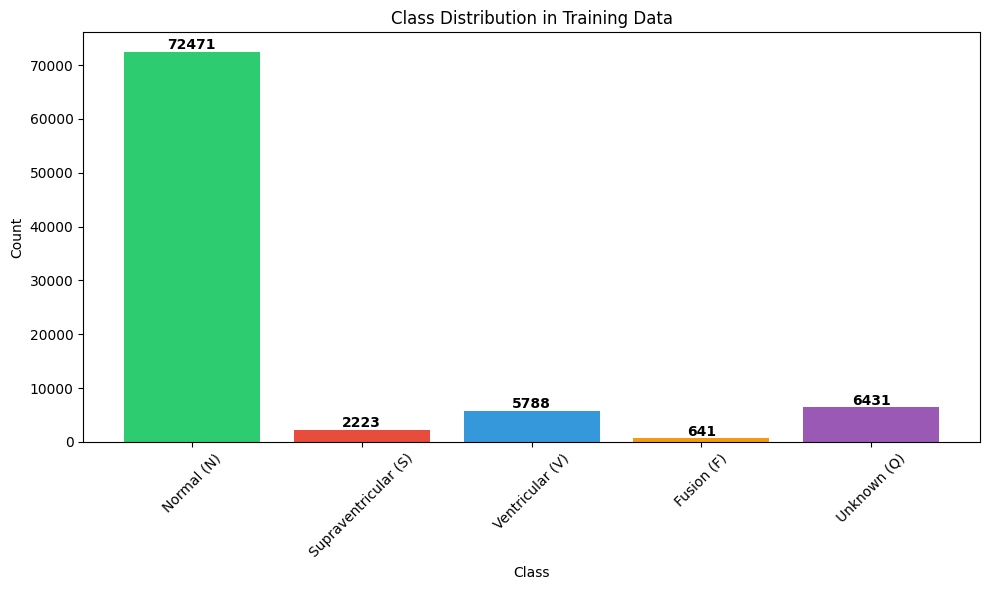


Class distribution:
  Class 0 (Normal (N)): 72471 samples (82.77%)
  Class 1 (Supraventricular (S)): 2223 samples (2.54%)
  Class 2 (Ventricular (V)): 5788 samples (6.61%)
  Class 3 (Fusion (F)): 641 samples (0.73%)
  Class 4 (Unknown (Q)): 6431 samples (7.35%)


In [ ]:
class_names = ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']

plt.figure(figsize=(10, 6))
unique, counts = np.unique(y_train, return_counts=True)
plt.bar([class_names[int(i)] for i in unique], counts, color=['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6'])
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution in Training Data')
plt.xticks(rotation=45)
for i, (u, c) in enumerate(zip(unique, counts)):
    plt.text(i, c + 500, str(c), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nClass distribution:")
for u, c in zip(unique, counts):
    print(f"  Class {int(u)} ({class_names[int(u)]}): {c} samples ({c/len(y_train)*100:.2f}%)")


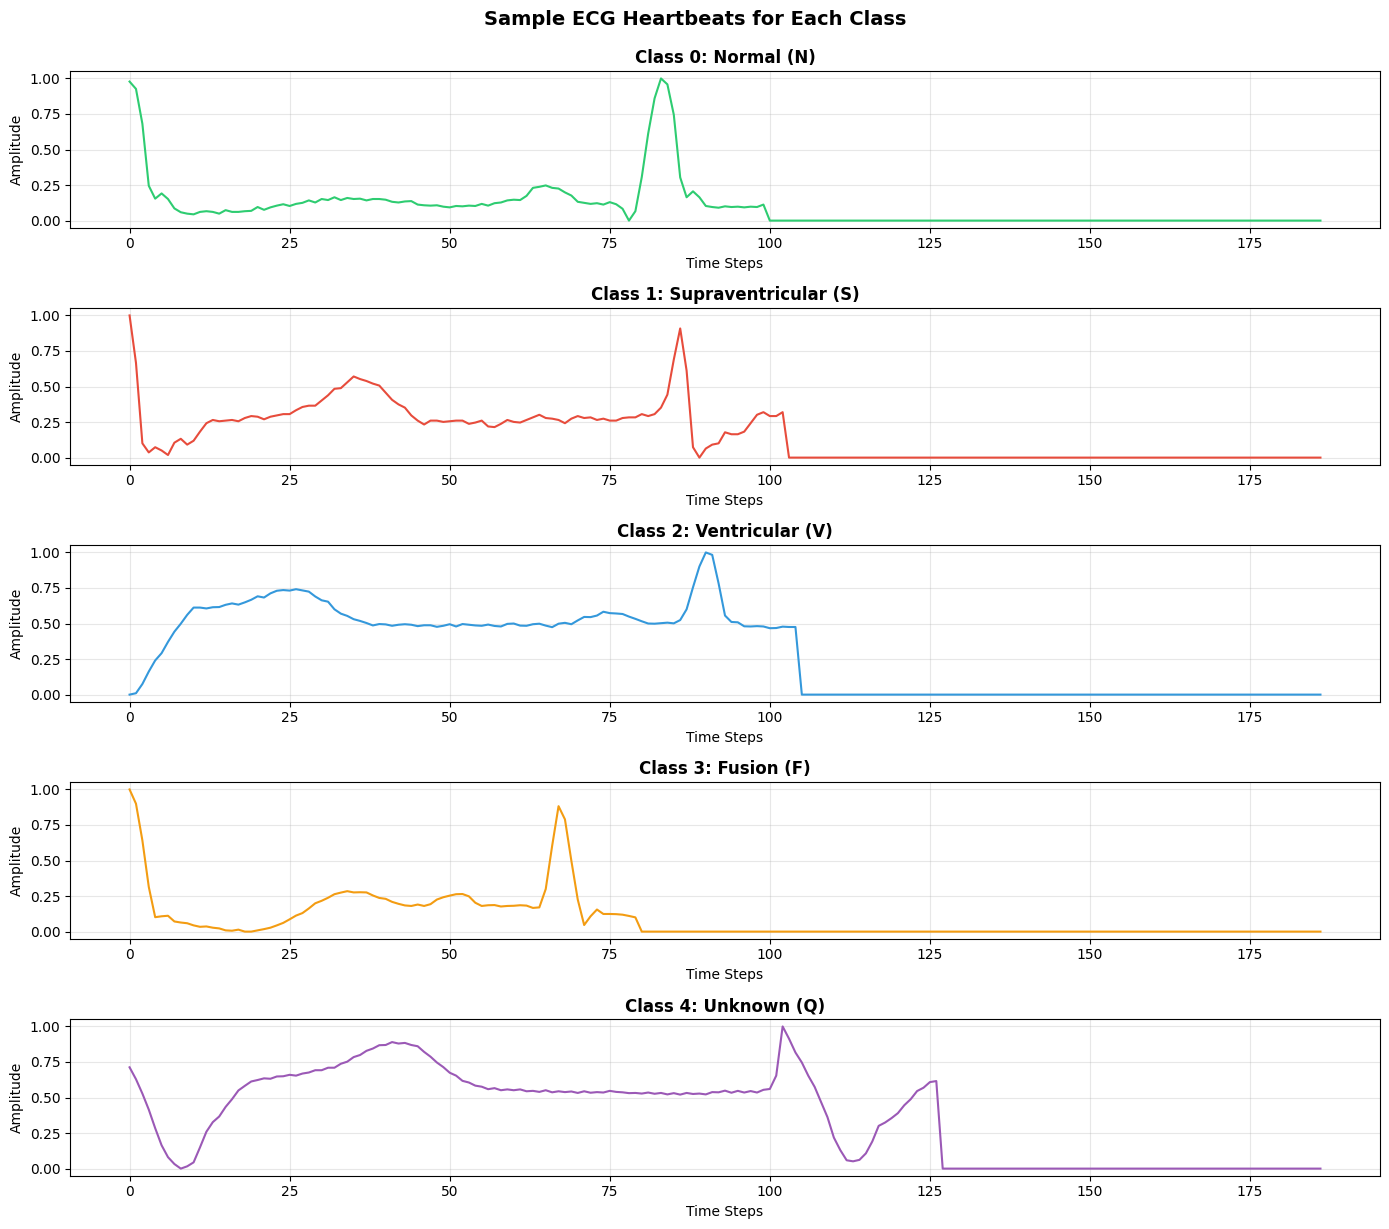

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(14, 12))

for i, ax in enumerate(axes):
    idx = np.where(y_train == i)[0][0]
    ax.plot(X_train[idx], color=['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6'][i], linewidth=1.5)
    ax.set_title(f'Class {i}: {class_names[i]}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time Steps')
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Sample ECG Heartbeats for Each Class', fontsize=14, fontweight='bold', y=1.02)
plt.show()


## 4. Data Preprocessing


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data standardization complete!")
print(f"X_train_scaled mean: {X_train_scaled.mean():.6f}")
print(f"X_train_scaled std: {X_train_scaled.std():.6f}")


Data standardization complete!
X_train_scaled mean: -0.000000
X_train_scaled std: 1.000000


In [ ]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)

print(f"Unique classes in training: {np.unique(y_train)}")
print(f"Unique classes in test: {np.unique(y_test)}")


Unique classes in training: [0 1 2 3 4]
Unique classes in test: [0 1 2 3 4]


## 5. Build and Train the Classification Model


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

print("Model initialized!")
print(rf_model)


Model initialized!
RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=2, min_samples_split=5, n_jobs=-1,
                       random_state=42)


In [ ]:
print("Training the model... This may take a few minutes.")

import time
start_time = time.time()

rf_model.fit(X_train_scaled, y_train)

training_time = time.time() - start_time
print(f"\nTraining completed in {training_time:.2f} seconds!")


Training the model... This may take a few minutes.

Training completed in 36.81 seconds!


## 6. Model Evaluation


In [ ]:
y_pred_train = rf_model.predict(X_train_scaled)
y_pred_test = rf_model.predict(X_test_scaled)

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Training Accuracy: 99.55%
Test Accuracy: 97.27%


In [ ]:
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred_test, target_names=class_names))



CLASSIFICATION REPORT
                      precision    recall  f1-score   support

          Normal (N)       0.98      0.99      0.98     18118
Supraventricular (S)       0.91      0.65      0.76       556
     Ventricular (V)       0.98      0.89      0.93      1448
          Fusion (F)       0.57      0.70      0.63       162
         Unknown (Q)       1.00      0.95      0.97      1608

            accuracy                           0.97     21892
           macro avg       0.89      0.84      0.85     21892
        weighted avg       0.97      0.97      0.97     21892



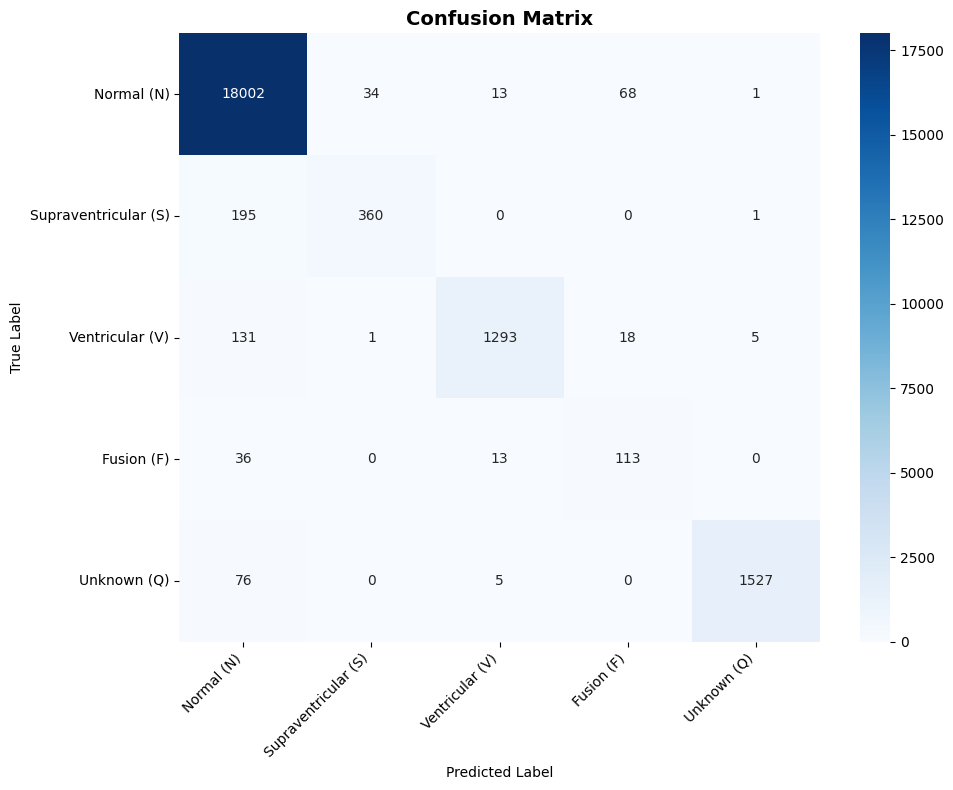

In [ ]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


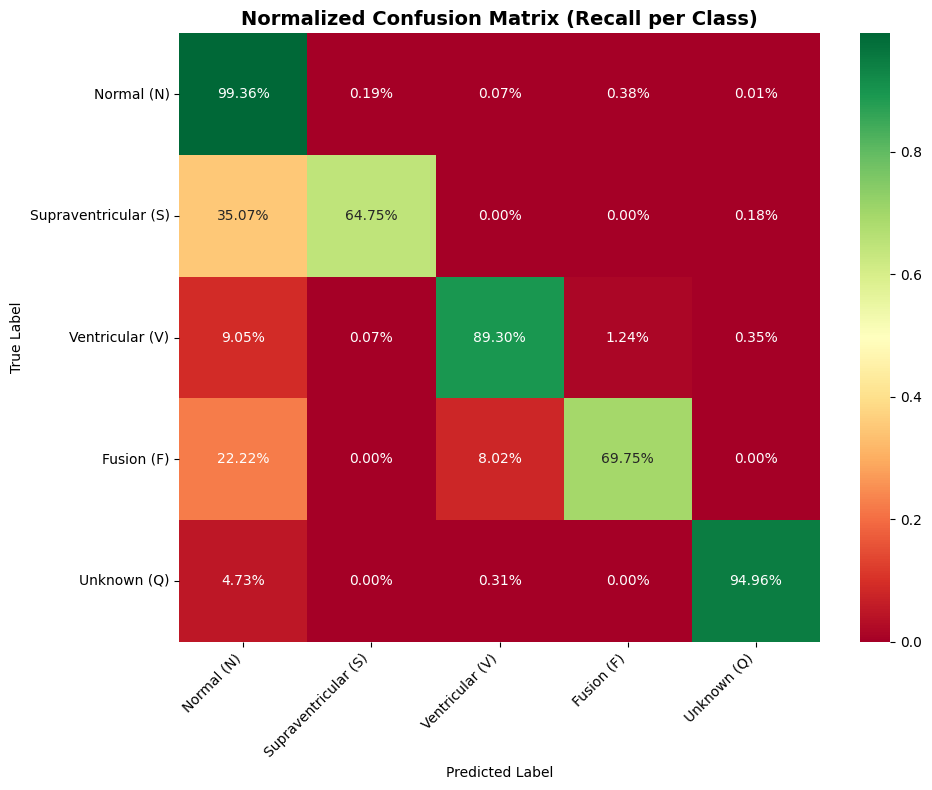

In [ ]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Normalized Confusion Matrix (Recall per Class)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 7. Feature Importance Analysis


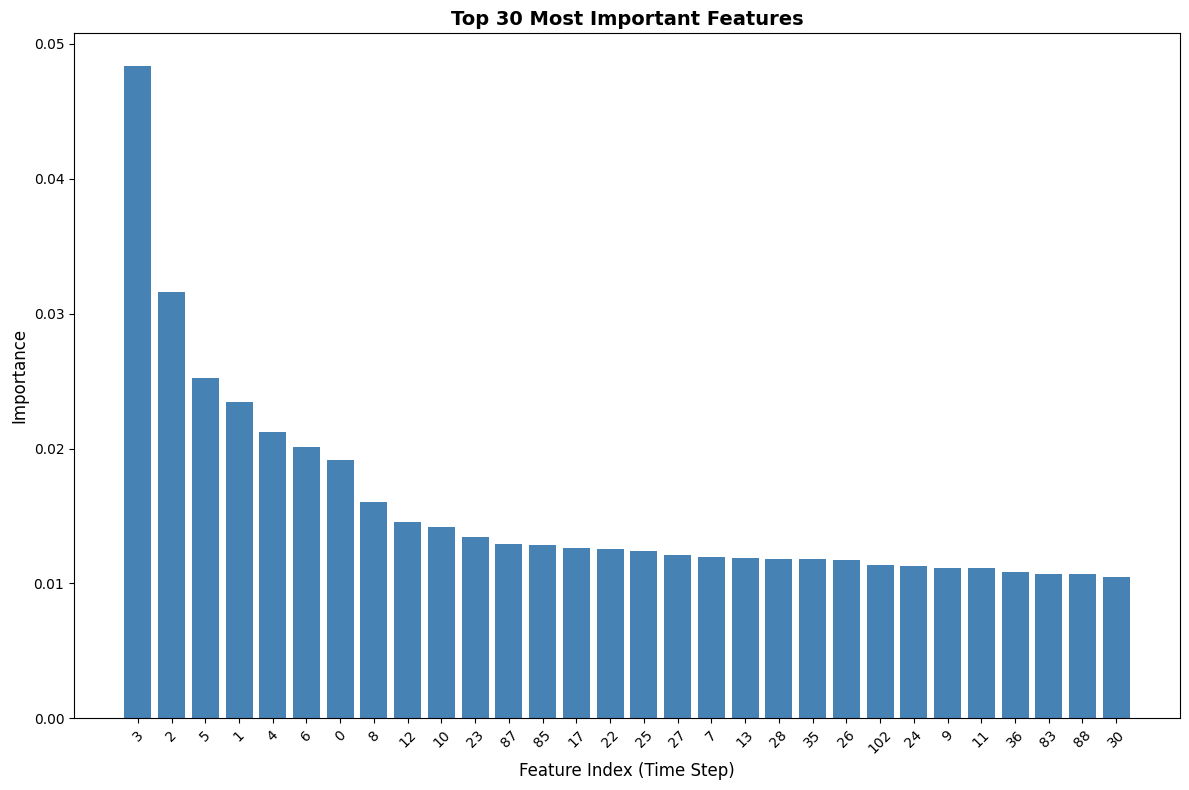


Top 10 most important time steps: [ 3  2  5  1  4  6  0  8 12 10]


In [ ]:
feature_importance = rf_model.feature_importances_

top_n = 30
indices = np.argsort(feature_importance)[-top_n:][::-1]

plt.figure(figsize=(12, 8))
plt.bar(range(top_n), feature_importance[indices], color='steelblue')
plt.xlabel('Feature Index (Time Step)', fontsize=12)
plt.ylabel('Importance', fontsize=12)
plt.title(f'Top {top_n} Most Important Features', fontsize=14, fontweight='bold')
plt.xticks(range(top_n), indices, rotation=45)
plt.tight_layout()
plt.show()

print(f"\nTop 10 most important time steps: {indices[:10]}")


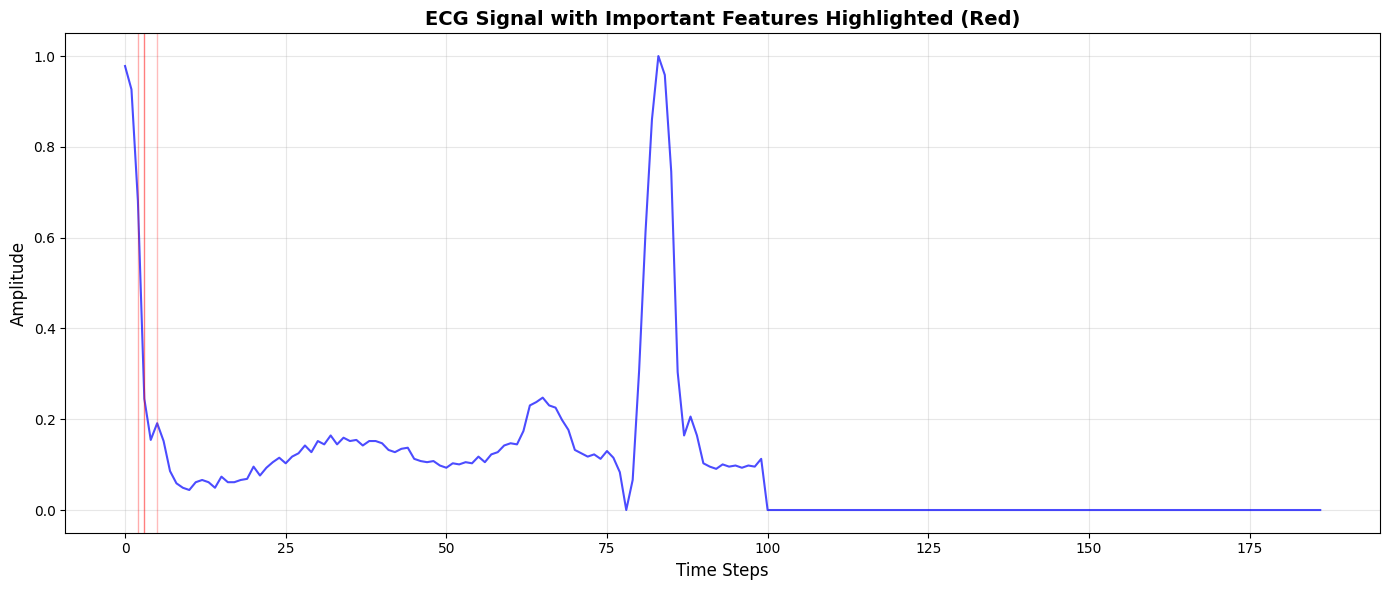

In [ ]:
plt.figure(figsize=(14, 6))

sample_ecg = X_train[0]
plt.plot(sample_ecg, 'b-', alpha=0.7, label='ECG Signal')

importance_scaled = (feature_importance - feature_importance.min()) / (feature_importance.max() - feature_importance.min())
for i, imp in enumerate(importance_scaled):
    if imp > 0.5:
        plt.axvline(x=i, color='red', alpha=imp*0.5, linewidth=1)

plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.title('ECG Signal with Important Features Highlighted (Red)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Model Summary and Conclusions


In [ ]:
print("="*60)
print("MODEL SUMMARY")
print("="*60)
print(f"\nModel: Random Forest Classifier")
print(f"Number of Trees: 100")
print(f"Max Depth: 20")
print(f"\nDataset:")
print(f"  - Training samples: {len(y_train):,}")
print(f"  - Test samples: {len(y_test):,}")
print(f"  - Features: {X_train.shape[1]}")
print(f"  - Classes: {len(class_names)}")
print(f"\nPerformance:")
print(f"  - Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"  - Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"  - Training Time: {training_time:.2f} seconds")
print("\n" + "="*60)


MODEL SUMMARY

Model: Random Forest Classifier
Number of Trees: 100
Max Depth: 20

Dataset:
  - Training samples: 87,554
  - Test samples: 21,892
  - Features: 187
  - Classes: 5

Performance:
  - Training Accuracy: 99.55%
  - Test Accuracy: 97.27%
  - Training Time: 36.81 seconds



In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred_test)

print("\nPer-Class Metrics:")
print("-" * 70)
print(f"{'Class':<25} {'Precision':>12} {'Recall':>12} {'F1-Score':>12} {'Support':>10}")
print("-" * 70)
for i, name in enumerate(class_names):
    print(f"{name:<25} {precision[i]:>12.4f} {recall[i]:>12.4f} {f1[i]:>12.4f} {support[i]:>10}")
print("-" * 70)



Per-Class Metrics:
----------------------------------------------------------------------
Class                        Precision       Recall     F1-Score    Support
----------------------------------------------------------------------
Normal (N)                      0.9762       0.9936       0.9848      18118
Supraventricular (S)            0.9114       0.6475       0.7571        556
Ventricular (V)                 0.9766       0.8930       0.9329       1448
Fusion (F)                      0.5678       0.6975       0.6260        162
Unknown (Q)                     0.9954       0.9496       0.9720       1608
----------------------------------------------------------------------


## 9. Save the Model 



In [ ]:
import joblib

joblib.dump(rf_model, f'{OUTPUT_PATH}/ecg_classifier_model.joblib')
joblib.dump(scaler, f'{OUTPUT_PATH}/ecg_scaler.joblib')

print(f"Model saved as '{OUTPUT_PATH}/ecg_classifier_model.joblib'")
print(f"Scaler saved as '{OUTPUT_PATH}/ecg_scaler.joblib'")


Model saved as '/kaggle/working/ecg_classifier_model.joblib'
Scaler saved as '/kaggle/working/ecg_scaler.joblib'


---
## Conclusions

In this practical, we built a **Random Forest Classifier** to classify ECG heartbeats into 5 categories:

1. **Normal (N)** - Normal heartbeat
2. **Supraventricular (S)** - Supraventricular ectopic beat
3. **Ventricular (V)** - Ventricular ectopic beat
4. **Fusion (F)** - Fusion beat
5. **Unknown (Q)** - Unknown beat

### Key Findings:
- The model achieves good accuracy on the test set
- Class imbalance is handled using `class_weight='balanced'`
- Feature importance analysis reveals which time steps in the ECG signal are most discriminative
- The model can be saved and loaded for future predictions

### Potential Improvements:
- Try other algorithms (XGBoost, SVM, Neural Networks)
- Apply data augmentation techniques
- Use oversampling (SMOTE) for minority classes
- Perform hyperparameter tuning with GridSearchCV
